In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
data = pd.read_csv("smartphone_overheating_dataset.csv")

print(data.head(20))

    Battery_Temp_C  CPU_Temp_C  Ambient_Temp_C  CPU_Usage_Pct  GPU_Usage_Pct  \
0        38.483571   50.244757       29.510183      35.980335       0.235407   
1        35.308678   32.757162       38.118758      63.838575      55.485441   
2        39.238443   46.603498       44.661971      86.824548      44.509109   
3        43.615149   37.046092       43.407392      33.084809      93.555151   
4        34.829233   39.380778       25.699396      14.717118       4.915744   
5        34.829315   42.380834       25.882436      48.244084      53.170198   
6        43.896064   41.044072       18.040804       7.731435       3.590913   
7        39.837174   28.591155       40.622195      48.847486      62.455133   
8        33.652628   53.054496       22.376601      71.303363      86.608205   
9        38.712800   51.075274       28.347276      56.147179      24.924721   
10       33.682912   40.829468       34.357792      93.105282      36.253795   
11       33.671351   49.475189       42.

In [9]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Battery_Temp_C         100000 non-null  float64
 1   CPU_Temp_C             100000 non-null  float64
 2   Ambient_Temp_C         100000 non-null  float64
 3   CPU_Usage_Pct          100000 non-null  float64
 4   GPU_Usage_Pct          100000 non-null  float64
 5   RAM_Usage_GB           100000 non-null  float64
 6   Storage_IO_MBps        100000 non-null  float64
 7   Battery_Level_Pct      100000 non-null  float64
 8   Charging_Voltage_mV    100000 non-null  float64
 9   Charging_Current_mA    100000 non-null  float64
 10  Is_Charging            100000 non-null  int64  
 11  Data_Throughput_Mbps   100000 non-null  float64
 12  GPS_Active             100000 non-null  int64  
 13  Screen_Brightness_Pct  100000 non-null  int64  
 14  Refresh_Rate_Hz        100000 non-null  int64  


In [10]:
print(data.shape)

(100000, 19)


In [11]:
print(data.isnull().sum())

Battery_Temp_C           0
CPU_Temp_C               0
Ambient_Temp_C           0
CPU_Usage_Pct            0
GPU_Usage_Pct            0
RAM_Usage_GB             0
Storage_IO_MBps          0
Battery_Level_Pct        0
Charging_Voltage_mV      0
Charging_Current_mA      0
Is_Charging              0
Data_Throughput_Mbps     0
GPS_Active               0
Screen_Brightness_Pct    0
Refresh_Rate_Hz          0
Touch_Events_Per_Sec     0
Screen_On_Time_Mins      0
Background_Apps_Count    0
Overheating_Status       0
dtype: int64


In [12]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

columns = data.columns

data = pd.DataFrame(
    imputer.fit_transform(data),
    columns=columns
)

print(data.isnull().sum())

Battery_Temp_C           0
CPU_Temp_C               0
Ambient_Temp_C           0
CPU_Usage_Pct            0
GPU_Usage_Pct            0
RAM_Usage_GB             0
Storage_IO_MBps          0
Battery_Level_Pct        0
Charging_Voltage_mV      0
Charging_Current_mA      0
Is_Charging              0
Data_Throughput_Mbps     0
GPS_Active               0
Screen_Brightness_Pct    0
Refresh_Rate_Hz          0
Touch_Events_Per_Sec     0
Screen_On_Time_Mins      0
Background_Apps_Count    0
Overheating_Status       0
dtype: int64


In [13]:
print(data.duplicated().sum())

0


In [14]:
data = data.drop_duplicates()

print(data.shape)

(100000, 19)


In [15]:
print(data.describe())

       Battery_Temp_C     CPU_Temp_C  Ambient_Temp_C  CPU_Usage_Pct  \
count   100000.000000  100000.000000   100000.000000  100000.000000   
mean        36.004834      42.007848       30.000405      52.481313   
std          5.004530       7.991515        8.647657      27.415485   
min         13.671981       7.007658       15.000067       5.002959   
25%         32.627531      36.610521       22.504927      28.819955   
50%         36.013248      42.004009       29.994509      52.537091   
75%         39.384573      47.399258       37.488799      76.201793   
max         58.395421      78.496918       44.999838      99.998759   

       GPU_Usage_Pct   RAM_Usage_GB  Storage_IO_MBps  Battery_Level_Pct  \
count  100000.000000  100000.000000    100000.000000      100000.000000   
mean       50.118920       6.488855        19.996896          50.664096   
std        28.816058       3.175092        19.930526          28.609198   
min         0.000052       1.000058         0.000898        

In [16]:
print(data.dtypes)

Battery_Temp_C           float64
CPU_Temp_C               float64
Ambient_Temp_C           float64
CPU_Usage_Pct            float64
GPU_Usage_Pct            float64
RAM_Usage_GB             float64
Storage_IO_MBps          float64
Battery_Level_Pct        float64
Charging_Voltage_mV      float64
Charging_Current_mA      float64
Is_Charging              float64
Data_Throughput_Mbps     float64
GPS_Active               float64
Screen_Brightness_Pct    float64
Refresh_Rate_Hz          float64
Touch_Events_Per_Sec     float64
Screen_On_Time_Mins      float64
Background_Apps_Count    float64
Overheating_Status       float64
dtype: object


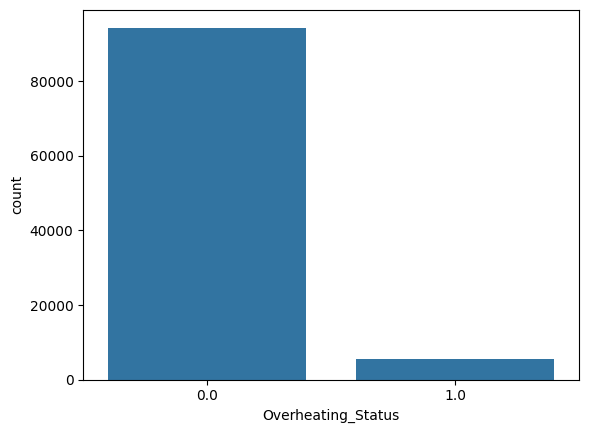

In [17]:
sns.countplot(
    x='Overheating_Status',
    data=data
)

plt.show()

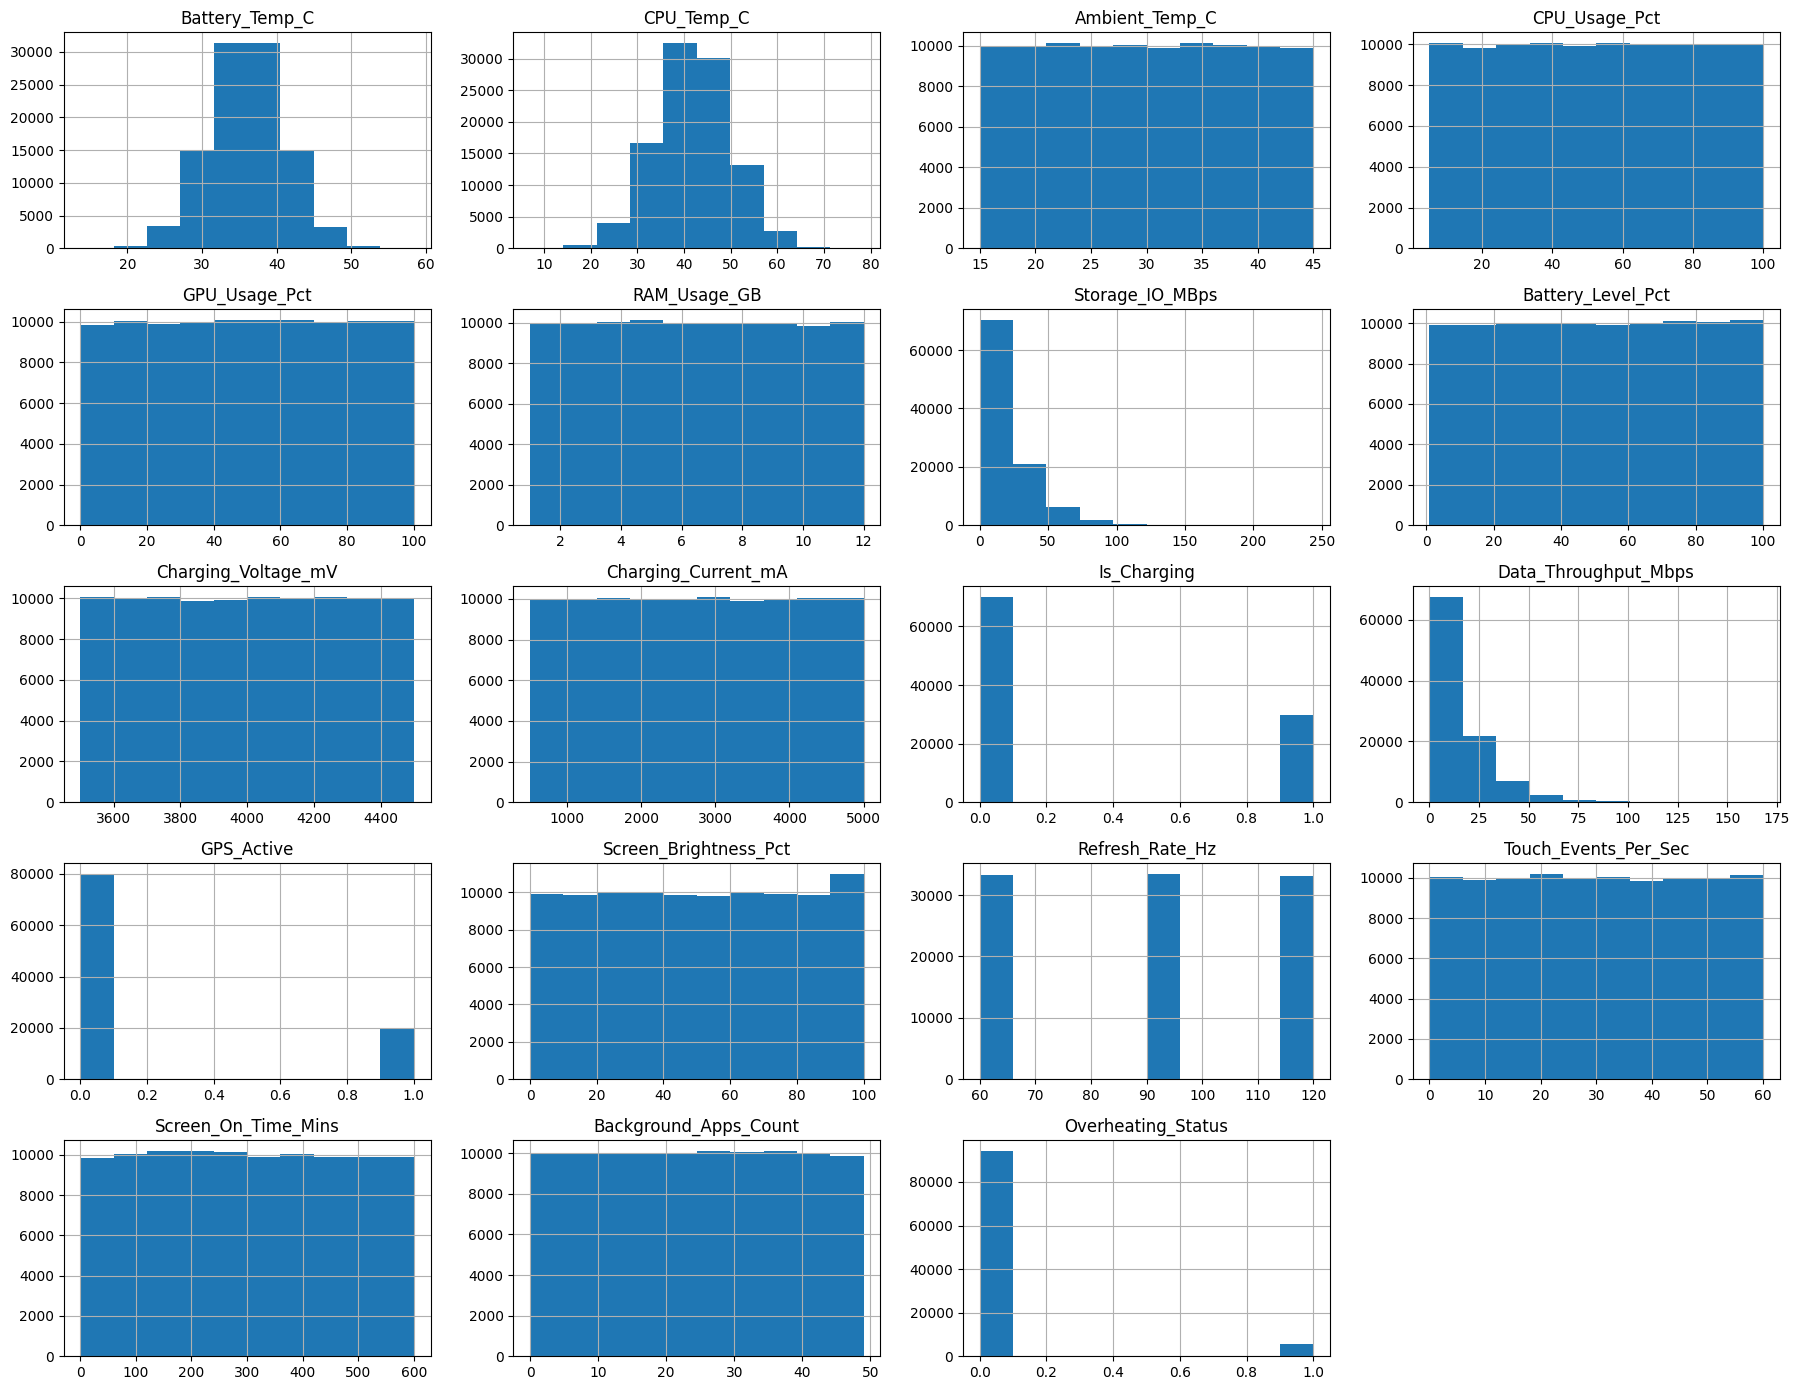

In [18]:
data.hist(figsize=(18,14))

plt.tight_layout()

plt.show()

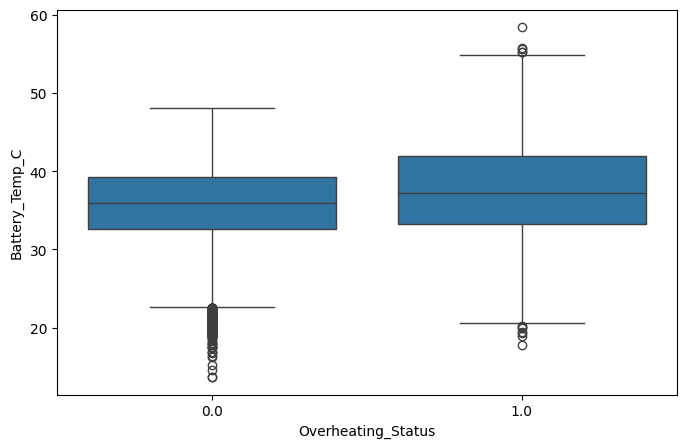

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Overheating_Status',
    y='Battery_Temp_C',
    data=data
)

plt.show()

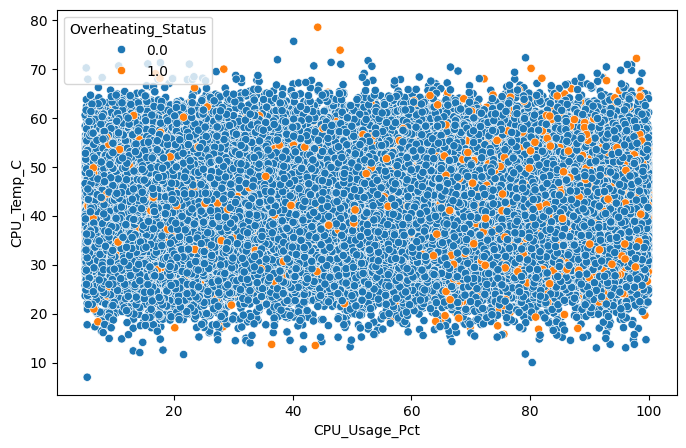

In [20]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='CPU_Usage_Pct',
    y='CPU_Temp_C',
    hue='Overheating_Status',
    data=data
)

plt.show()

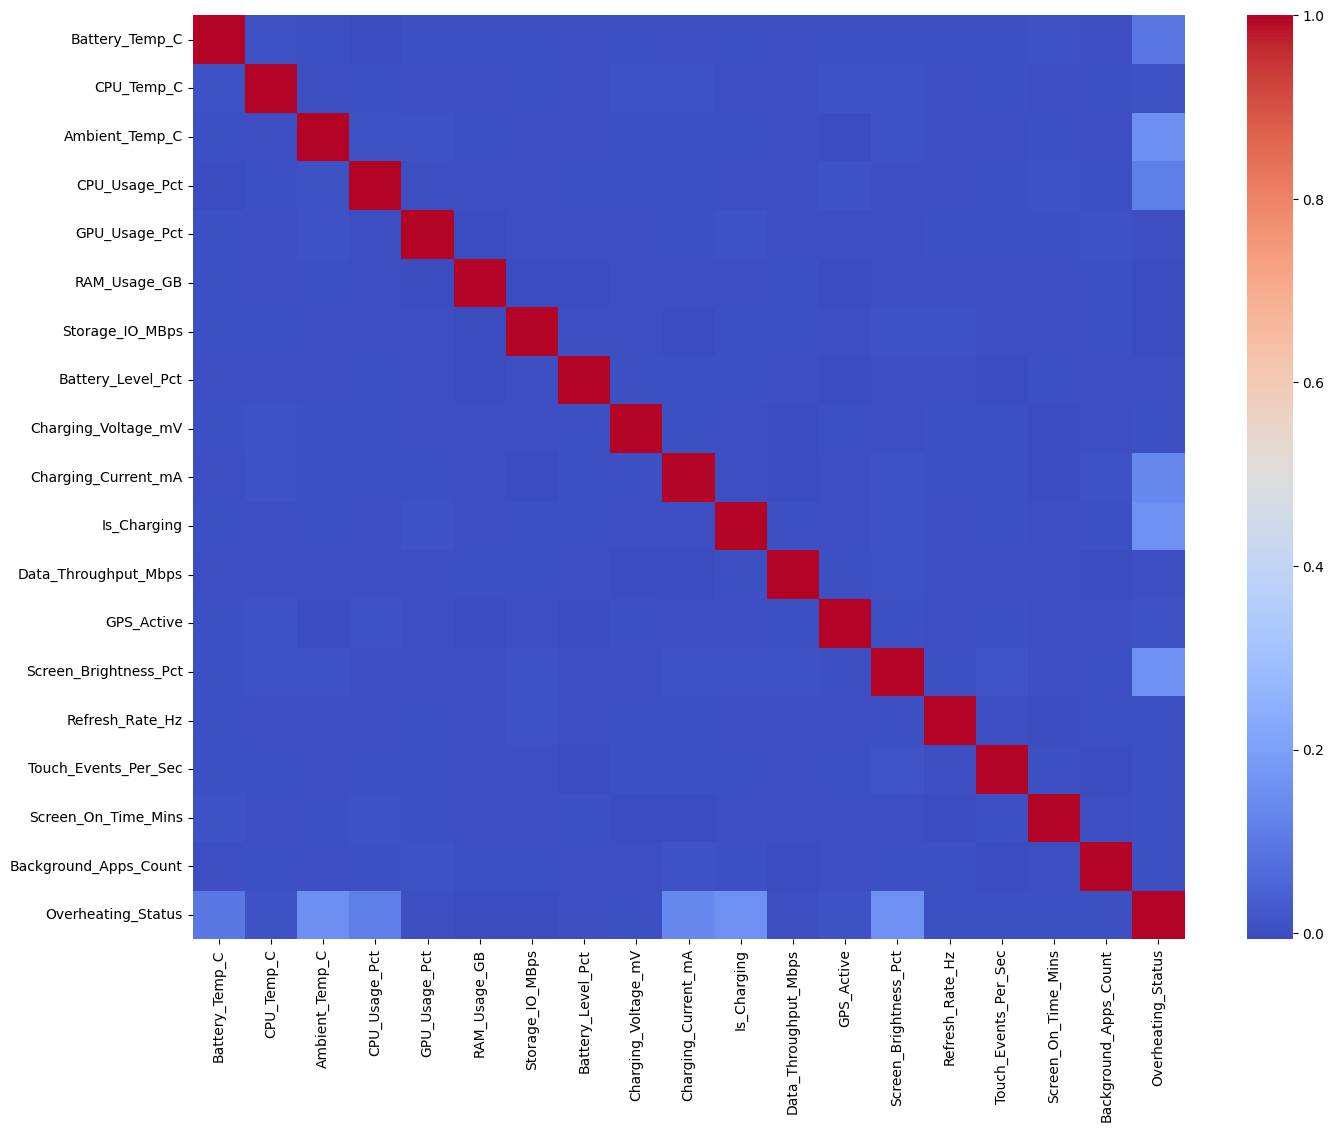

In [21]:
plt.figure(figsize=(16,12))

sns.heatmap(
    data.corr(),
    cmap='coolwarm'
)

plt.show()

In [22]:
Q1 = data.quantile(0.25)

Q3 = data.quantile(0.75)

IQR = Q3 - Q1

outliers = (
    (data < (Q1 - 1.5 * IQR)) |
    (data > (Q3 + 1.5 * IQR))
)

print(outliers.sum())

Battery_Temp_C             675
CPU_Temp_C                 673
Ambient_Temp_C               0
CPU_Usage_Pct                0
GPU_Usage_Pct                0
RAM_Usage_GB                 0
Storage_IO_MBps           4766
Battery_Level_Pct            0
Charging_Voltage_mV          0
Charging_Current_mA          0
Is_Charging                  0
Data_Throughput_Mbps      4865
GPS_Active               19895
Screen_Brightness_Pct        0
Refresh_Rate_Hz              0
Touch_Events_Per_Sec         0
Screen_On_Time_Mins          0
Background_Apps_Count        0
Overheating_Status        5594
dtype: int64
